In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import sys
from bmtk.utils.reports.spike_trains import PoissonSpikeGenerator
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


from modules import spike_train_generation

# Read In Data

In [2]:
# Read in bio data if applicable
PFR = pd.read_csv("pyrFiringRateAvg.csv",delimiter=",")
PFR_time_shortened = np.array(PFR['Time'][PFR['Time'] >0])
PFR_firing_rate_shortened = np.array(PFR['AvgFiringRate'][PFR['Time'] >0])

# Generate Spike Trains for Synaptic Stim Input

### Background Stimulus Input Generation

In [3]:
def homogeneous_poisson_timestamps(rate_hz, duration_ms):
    """
    Generate spike times for a homogeneous Poisson process.

    Parameters:
        rate_hz (float): desired firing rate in Hz.
        duration_ms (float): total time to generate over, in milliseconds.

    Returns:
        spike_times (list of float): spike timestamps in ms.
    """
    spike_times = []
    t = 000 # for bg input starting at tstart, should change to be input
    while t < duration_ms:
        isi = np.random.exponential(1000.0 / rate_hz)  # ISI in ms
        t += isi
        if t < duration_ms:
            spike_times.append(t)
    return spike_times

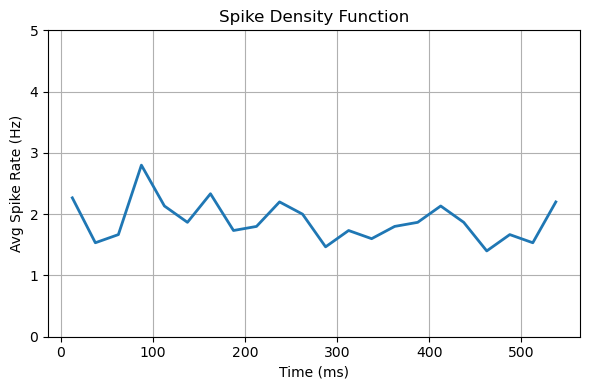

In [4]:
# Spike Train Generation
N_bg = 600
rate_hz = 2
duration_ms = 550

all_bg_spikes = []

for i in range(N_bg):
    bg_spikes = homogeneous_poisson_timestamps(rate_hz, duration_ms)
    all_bg_spikes.append(bg_spikes)

df = pd.DataFrame([{'node_ids': node_id, 'timestamps': t} for node_id, times in enumerate(all_bg_spikes) for t in times])
grouped_bg = df.groupby('node_ids')['timestamps'].apply(list).reset_index()


# Plotting
bin_width = 25  # ms

# Bin edges and centers
bins = np.arange(0, duration_ms + bin_width, bin_width)
bin_centers = bins[:-1] + bin_width / 2

# Flatten all spike times
all_spike_times = np.concatenate(grouped_bg['timestamps'].values)

# Histogram spike counts across all neurons
spike_counts, _ = np.histogram(all_spike_times, bins=bins)

# Convert to average firing rate per neuron (Hz)
# Hz = spikes / (bin width in sec) / num_neurons
spike_rate = spike_counts / (bin_width / 1000.0) / N_bg

# Plot
plt.figure(figsize=(6, 4))
plt.plot(bin_centers, spike_rate, lw=2)
plt.xlabel("Time (ms)")
plt.ylabel("Avg Spike Rate (Hz)")
plt.ylim(0,5)
plt.title("Spike Density Function")
plt.grid(True)
plt.tight_layout()
plt.show()


### Active Stimulus Input Generation

In [5]:
def inhomogeneous_poisson_through_num_points(lambdas, win_length):
    t = np.zeros(len(lambdas) * win_length)
    lambdas = np.divide(lambdas,1000/win_length)
    
    for i, lambd in enumerate(lambdas):

        num_points = np.random.poisson(lambd)

        if num_points >= win_length:
            t[i * win_length : (i + 1) * win_length] = 1
            continue

        random_inds = np.random.choice(a = np.arange(win_length), size = num_points, replace = False)
        spikes = np.zeros(win_length)
        spikes[random_inds] = 1
        t[i * win_length : (i + 1) * win_length] = spikes

    return t

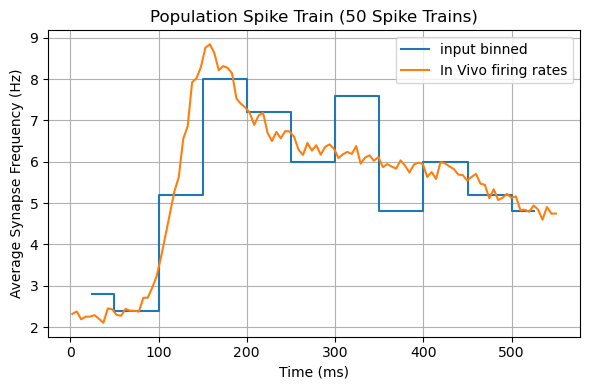

In [33]:
N_stim = 50
duration_ms = 550
bin_size = 5 #ms

all_spike_times = []

for i in range(N_stim):

    spikes=inhomogeneous_poisson_through_num_points(PFR_firing_rate_shortened,int(bin_size))
    time = np.arange(len(spikes))
    timestamps = time[spikes==1]
    all_spike_times.append(timestamps)


df = pd.DataFrame([{'node_ids': node_id, 'timestamps': t} for node_id, times in enumerate(all_spike_times) for t in times])
grouped_stim = df.groupby('node_ids')['timestamps'].apply(list).reset_index()
len(grouped_stim["timestamps"][0])



# Step 1: Combine all spike times into one flat array
all_spike_times = np.concatenate(grouped_stim['timestamps'].values)


# Step 2: Define bins
bin_width = 50  # ms
t_min = 0
t_max = duration_ms
bins = np.arange(t_min, t_max + bin_width, bin_width)  # edges
counts, _ = np.histogram(all_spike_times, bins=bins)
freqs = np.multiply(counts,1000/bin_width)
avg_freqs = np.divide(freqs,N_stim)  
# Step 3: Plot as vertical lines or bar graph
bin_centers = bins[:-1] + bin_width / 2

plt.figure(figsize=(6, 4))

# Option 1: Line plot (PSTH style)
plt.plot(bin_centers, avg_freqs, drawstyle='steps-mid',label = "input binned")
plt.plot(PFR_time_shortened*1000,PFR_firing_rate_shortened,label = "In Vivo firing rates")
plt.xlabel('Time (ms)')
# plt.ylabel('Spike Count (per bin)')
plt.ylabel('Average Synapse Frequency (Hz)')
plt.title(f'Population Spike Train ({N_stim} Spike Trains)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()
